# 🔄 Function Transformation — California Housing Dataset


**Dataset:** `sklearn.datasets.fetch_california_housing`

**Main idea:** Function transformation changes the mathematical representation of a feature (for example, `log1p(x)`) to make a skewed distribution more suitable for some machine-learning models.

## 📚 Learning Objectives

By the end of this notebook, you will be able to:

1. Understand why function transformation is used.
2. Identify skewed features in the California Housing dataset.
3. Apply `FunctionTransformer`.
4. Compare Logistic/Classification-style workflow from the reference notebook with a **regression-appropriate** workflow.
5. Compare Linear Regression and Decision Tree performance before and after transformation.
6. Use `ColumnTransformer` to transform selected columns only.
7. Visualize distributions and QQ plots before and after transformation.

In [1]:
# 📦 Import required libraries

import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1️⃣ Load the California Housing Dataset

In [2]:
# Load California housing dataset
california = fetch_california_housing(as_frame=True)

df = california.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Basic information
print("\nData types:")
print(df.dtypes)

Shape: (20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


### 🎯 Target Variable

The target column is:

`MedHouseVal` → median house value.

All other columns are input features.

In [4]:
# Check missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## 2️⃣ Separate Features and Target

In [5]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 8)
y shape: (20640,)


In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (16512, 8)
X_test : (4128, 8)


## 3️⃣ 🔍 Inspect Feature Distributions

Function transformation is especially useful when a feature is strongly skewed.

A common transformation is:

$$
x' = \log(1+x)
$$

We use `log1p(x)` because it safely computes `log(1 + x)` and is suitable when the feature contains zero values.

In [7]:
# Numerical summary
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,16512.0,3.880754,1.904294,0.499900,2.566700,3.545800,4.773175,15.000100
HouseAge,16512.0,28.608285,12.602499,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,16512.0,5.435235,2.387375,0.888889,4.452055,5.235874,6.061037,141.909091
AveBedrms,16512.0,1.096685,0.433215,0.333333,1.006508,1.049286,1.100348,25.636364
Population,16512.0,1426.453004,1137.056380,3.000000,789.000000,1167.000000,1726.000000,35682.000000
AveOccup,16512.0,3.096961,11.578744,0.692308,2.428799,2.817240,3.280000,1243.333333
Latitude,16512.0,35.643149,2.136665,32.550000,33.930000,34.260000,37.720000,41.950000
Longitude,16512.0,-119.582290,2.005654,-124.350000,-121.810000,-118.510000,-118.010000,-114.310000


In [8]:
# Skewness of each feature
skewness = X_train.skew().sort_values(ascending=False)

skewness

AveOccup      88.052663
AveBedrms     23.170746
AveRooms      18.607090
Population     5.276131
MedInc         1.634090
Latitude       0.461504
HouseAge       0.063453
Longitude     -0.288418
dtype: float64

## 📊 What is Skewness?

Skewness tells us how asymmetric the distribution of a variable is around its mean.

In simple terms:

It tells you whether the data is balanced or has a long tail toward one side.

Basic interpretation
| Skewness	| Meaning |
|-----------|---------------------------------|
|≈ 0	| Approximately symmetric|
|0 to 0.5	| Slightly right-skewed|
|0.5 to 1 |	Moderately right-skewed|
|> 1 |	Highly right-skewed|
|-0.5 to 0 |	Slightly left-skewed|
|-1 to -0.5	|Moderately left-skewed|
|< -1	| Highly left-skewed|

These are rules of thumb, not strict mathematical boundaries.

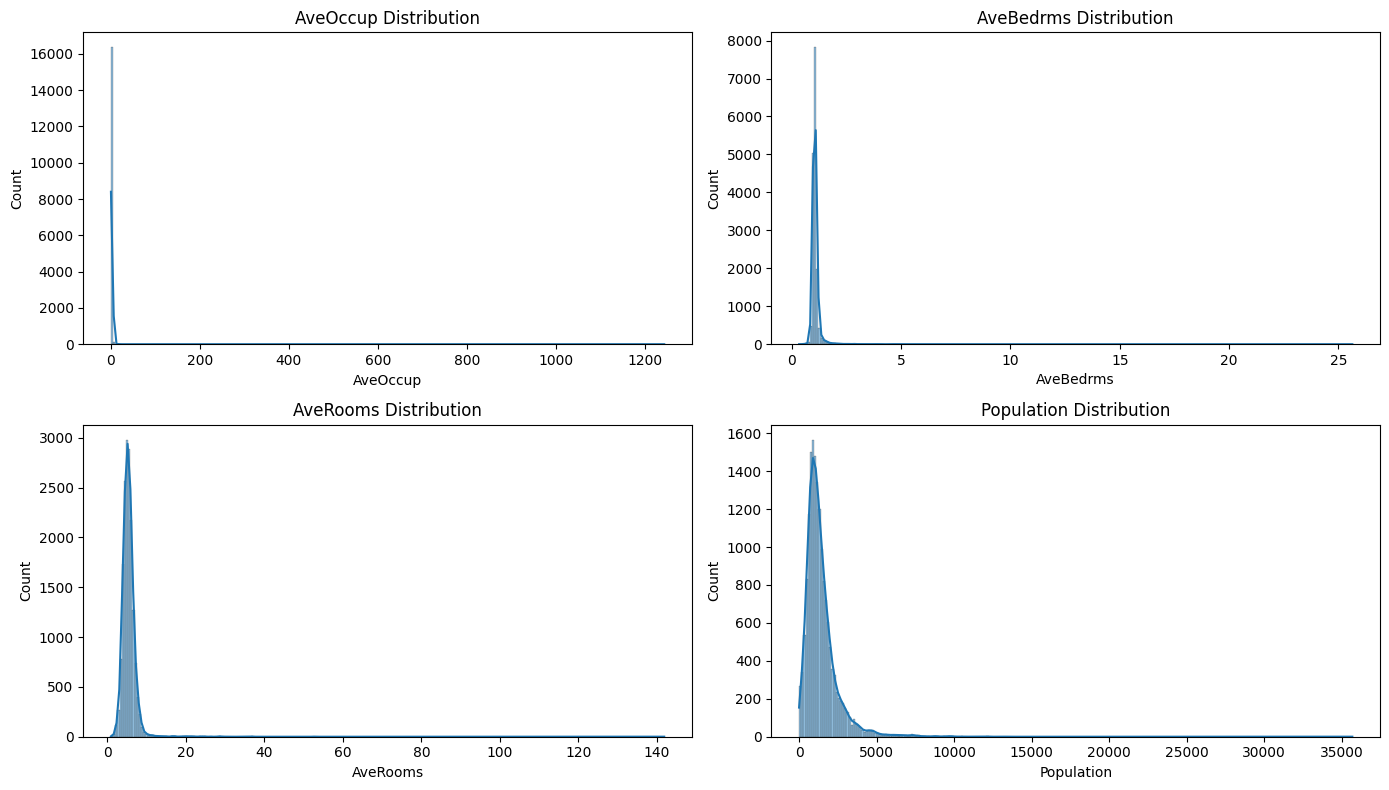

In [9]:
# Plot distributions of the most positively skewed features

top_features = skewness.abs().sort_values(ascending=False).head(4).index

plt.figure(figsize=(14, 8))

for i, col in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(X_train[col], kde=True)
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

## 4️⃣ 📊 Before Transformation — QQ Plots

A QQ plot helps compare the distribution of a feature with a theoretical normal distribution.

The reference notebook uses PDF/distribution plots and QQ plots before applying `FunctionTransformer`. fileciteturn0file0L283-L293

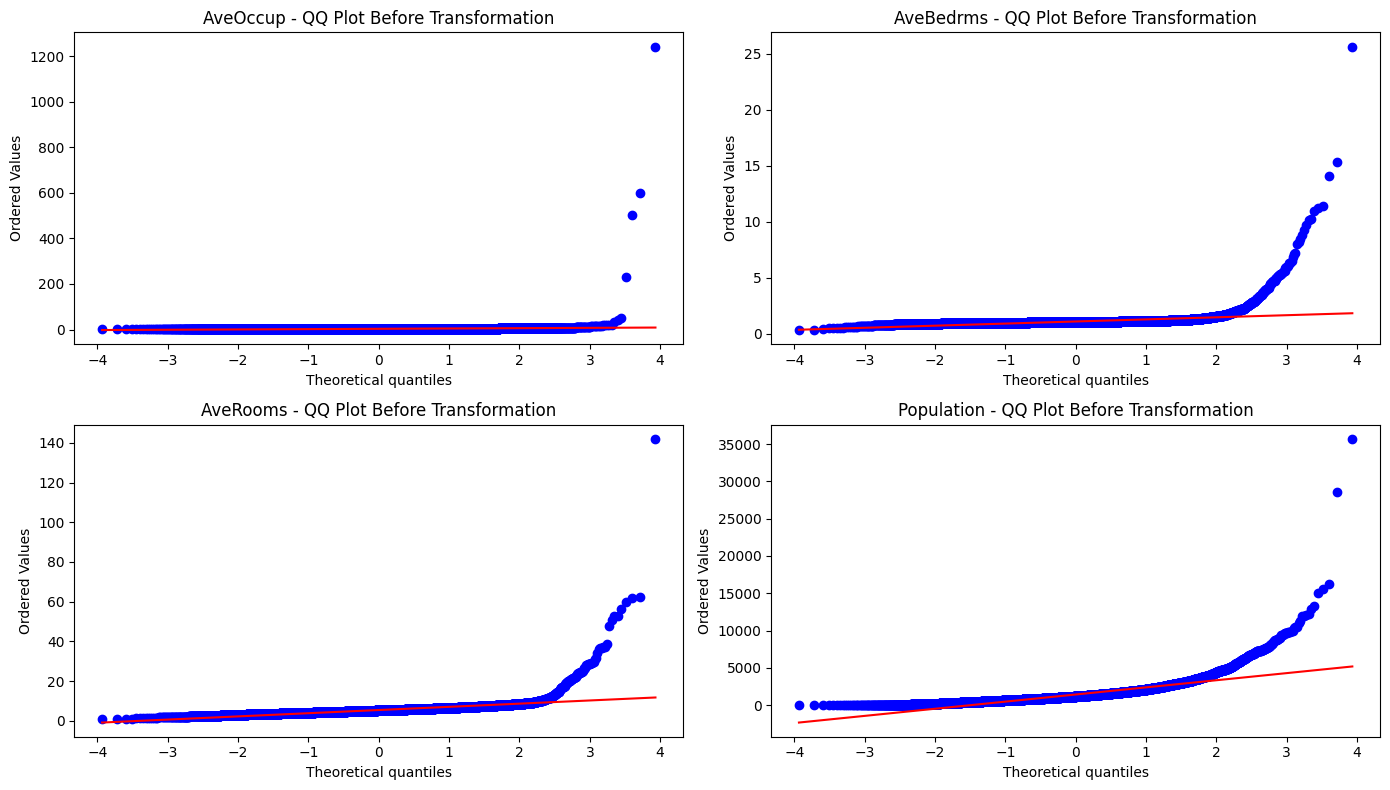

In [10]:
# QQ plots for selected skewed features

plt.figure(figsize=(14, 8))

for i, col in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f"{col} - QQ Plot Before Transformation")

plt.tight_layout()
plt.show()

## 5️⃣ 🤖 Baseline Models

The reference notebook creates baseline models, evaluates them, then applies:

```python
FunctionTransformer(func=np.log1p)
```

and evaluates the transformed data again. fileciteturn1file0L69-L85

Because California Housing is a **regression** dataset, we use `LinearRegression` and `DecisionTreeRegressor` here instead of the classification models used in the reference notebook.

In [11]:
# Baseline models

lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)

print("Linear Regression")
print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R2  :", r2_score(y_test, lr_pred))

print("\nDecision Tree")
print("RMSE:", mean_squared_error(y_test, dt_pred) ** 0.5)
print("R2  :", r2_score(y_test, dt_pred))

Linear Regression
RMSE: 0.7455813830127764
R2  : 0.5757877060324508

Decision Tree
RMSE: 0.7037294974840077
R2  : 0.622075845135081


## 6️⃣ 🔄 Apply Function Transformation

Following the reference notebook, create a `FunctionTransformer` using `np.log1p`. fileciteturn1file0L69-L85

Here we apply it to **selected skewed columns**, rather than blindly transforming every feature.

This is important because a mathematical transformation should be chosen based on the feature's distribution and domain.

In [13]:
# Function Transformer
log_transformer = FunctionTransformer(
    func=np.log1p,
    feature_names_out="one-to-one"
)

# Copy original datasets
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

for col in top_features:

    X_train_transformed[col] = (
        log_transformer.fit_transform(X_train[[col]])
        .to_numpy()
        .ravel()
    )

    X_test_transformed[col] = (
        log_transformer.transform(X_test[[col]])
        .to_numpy()
        .ravel()
    )

X_train_transformed.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,1.794698,0.696352,7.741099,1.545819,32.71,-117.03
8267,3.8125,49.0,1.699926,0.713442,7.181592,1.007263,33.77,-118.16
17445,4.1563,4.0,1.893990,0.685679,6.820016,1.314587,34.66,-120.48
14265,1.9425,36.0,1.610001,0.709907,7.257708,1.608311,32.69,-117.11
2271,3.5542,43.0,1.983539,0.758097,6.774224,1.193922,36.78,-119.80


In [14]:
# Compare skewness before and after transformation

comparison = pd.DataFrame({
    "Before": X_train[top_features].skew(),
    "After": X_train_transformed[top_features].skew()
})

comparison

,Before,After
AveOccup,88.052663,4.264825
AveBedrms,23.170746,8.662134
AveRooms,18.607090,1.338340
Population,5.276131,-1.034675


## 7️⃣ 📈 After Transformation — Distribution

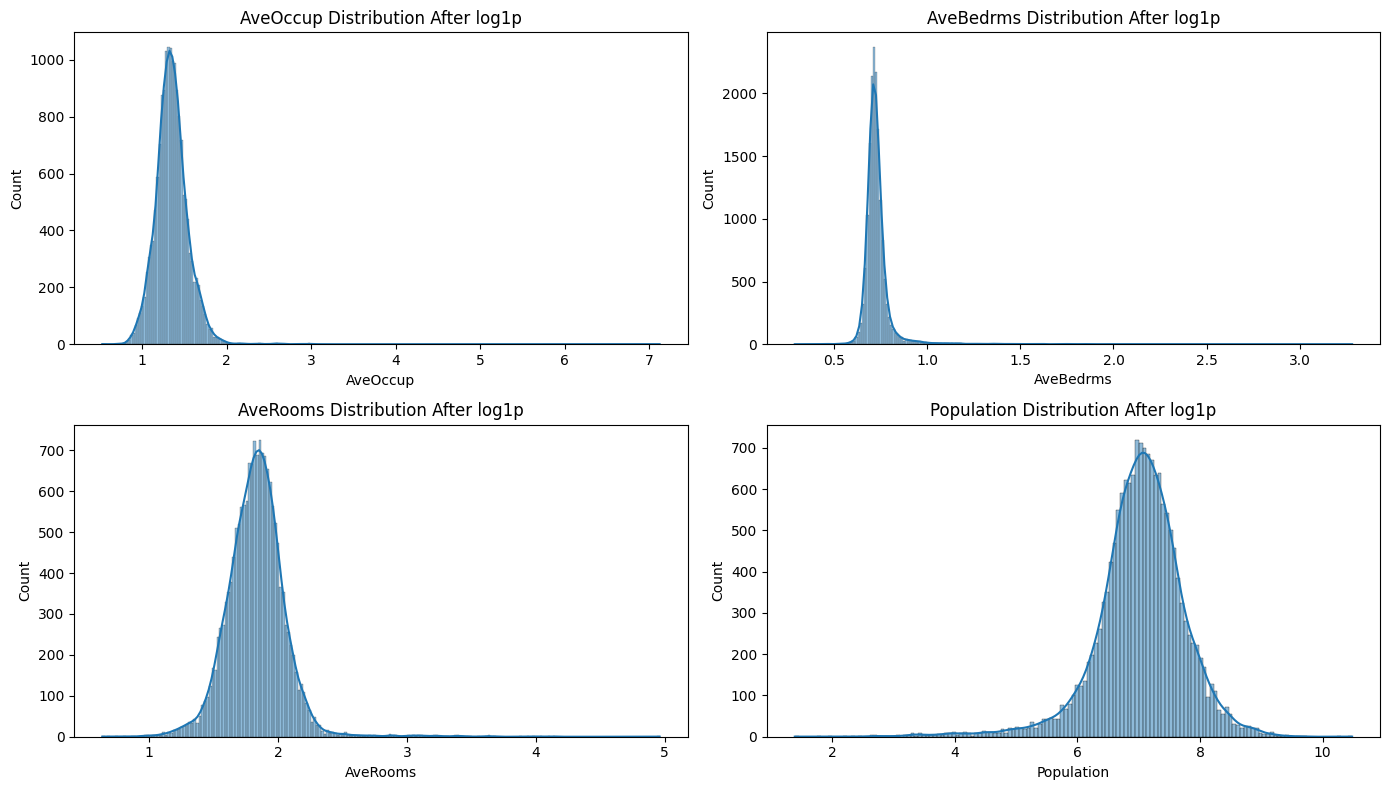

In [15]:
plt.figure(figsize=(14, 8))

for i, col in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(X_train_transformed[col], kde=True)
    plt.title(f"{col} Distribution After log1p")

plt.tight_layout()
plt.show()

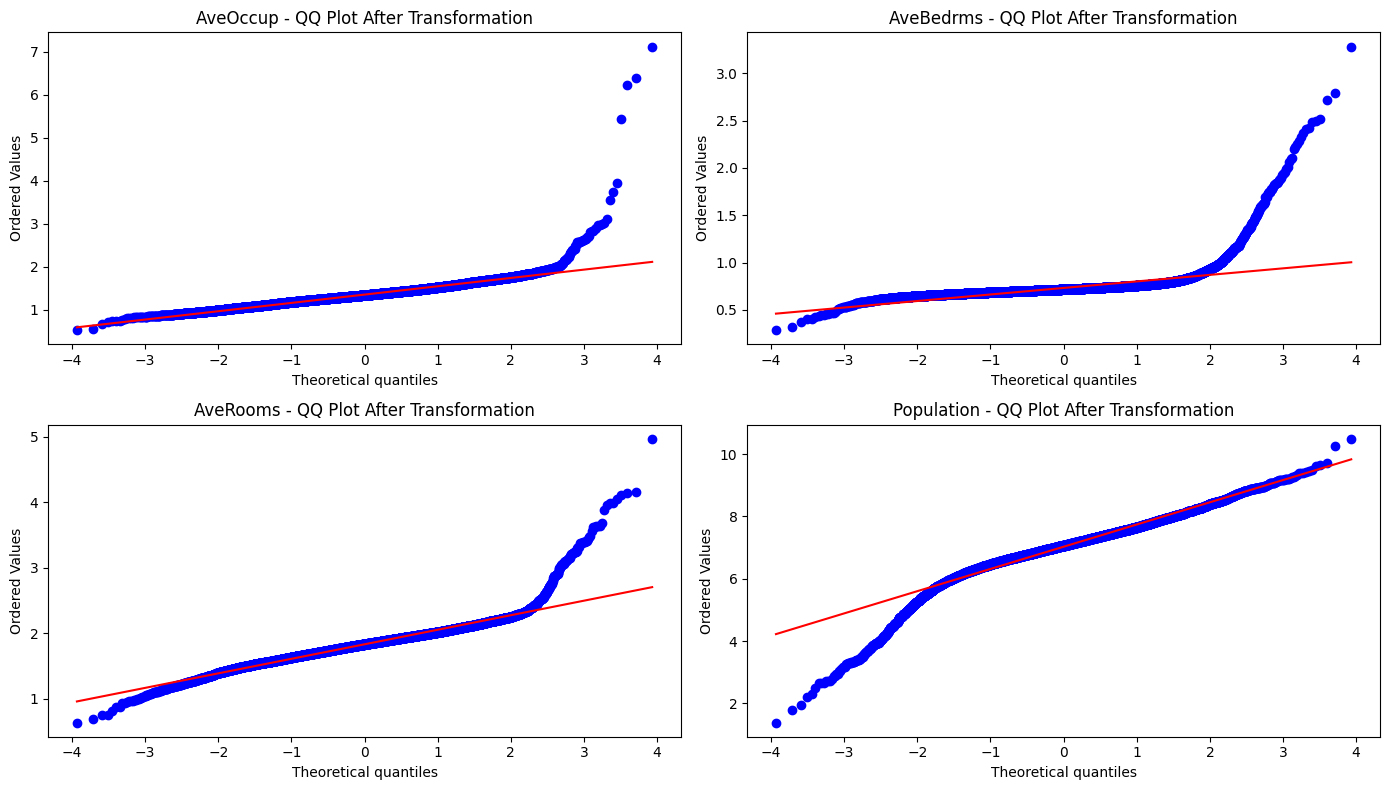

In [16]:
# QQ plots after transformation

plt.figure(figsize=(14, 8))

for i, col in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
    plt.title(f"{col} - QQ Plot After Transformation")

plt.tight_layout()
plt.show()

## 8️⃣ 🧪 Train Models on Transformed Features

The reference notebook retrains its models using `X_train_transformed` and evaluates them on `X_test_transformed`. fileciteturn1file0L88-L113

In [17]:
# Train models on transformed data

lr_transformed = LinearRegression()
dt_transformed = DecisionTreeRegressor(random_state=42)

lr_transformed.fit(X_train_transformed, y_train)
dt_transformed.fit(X_train_transformed, y_train)

lr_pred_transformed = lr_transformed.predict(X_test_transformed)
dt_pred_transformed = dt_transformed.predict(X_test_transformed)

print("Linear Regression - Transformed")
print("RMSE:", mean_squared_error(y_test, lr_pred_transformed) ** 0.5)
print("R2  :", r2_score(y_test, lr_pred_transformed))

print("\nDecision Tree - Transformed")
print("RMSE:", mean_squared_error(y_test, dt_pred_transformed) ** 0.5)
print("R2  :", r2_score(y_test, dt_pred_transformed))

Linear Regression - Transformed
RMSE: 0.6832669908810012
R2  : 0.6437342932018939

Decision Tree - Transformed
RMSE: 0.7036769899714712
R2  : 0.6221322392952333


## 9️⃣ 🔁 Cross-Validation Comparison

The reference notebook also compares transformed models using 10-fold cross-validation. fileciteturn1file0L115-L137

For regression, we use **negative RMSE** as the scoring metric because lower RMSE is better.

In [18]:
# Cross-validation

lr_cv_before = cross_val_score(
    LinearRegression(),
    X,
    y,
    scoring="neg_root_mean_squared_error",
    cv=10
)

lr_cv_after = cross_val_score(
    LinearRegression(),
    X_train_transformed,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=10
)

print("Linear Regression CV RMSE Before:", -lr_cv_before.mean())
print("Linear Regression CV RMSE After :", -lr_cv_after.mean())

Linear Regression CV RMSE Before: 0.7307403363151843
Linear Regression CV RMSE After : 0.6734664665590984


## 🔟 🧩 Using ColumnTransformer

For a real ML pipeline, it is cleaner to transform selected columns using `ColumnTransformer`.

This avoids manually transforming training and test data and helps prevent inconsistent preprocessing.

In [19]:
# ColumnTransformer pipeline

transformer = ColumnTransformer(
    transformers=[
        (
            "log_transform",
            FunctionTransformer(
                func=np.log1p,
                feature_names_out="one-to-one"
            ),
            list(top_features)
        )
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("transform", transformer),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

pipeline_pred = pipeline.predict(X_test)

print("Pipeline RMSE:", mean_squared_error(y_test, pipeline_pred) ** 0.5)
print("Pipeline R2  :", r2_score(y_test, pipeline_pred))

Pipeline RMSE: 0.6832669908810012
Pipeline R2  : 0.6437342932018939


## 1️⃣1️⃣ 📋 Compare Results

Use this table to understand whether function transformation actually helped the model.

> **Important:** Function transformation does not guarantee better performance. It is useful when it makes the relationship between features and target easier for the chosen model to learn.

In [20]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression - Before",
        "Linear Regression - After",
        "Decision Tree - Before",
        "Decision Tree - After"
    ],
    "RMSE": [
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, lr_pred_transformed) ** 0.5,
        mean_squared_error(y_test, dt_pred) ** 0.5,
        mean_squared_error(y_test, dt_pred_transformed) ** 0.5
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, lr_pred_transformed),
        r2_score(y_test, dt_pred),
        r2_score(y_test, dt_pred_transformed)
    ]
})

results

,Model,RMSE,R2
0,Linear Regression - Before,0.745581,0.575788
1,Linear Regression - After,0.683267,0.643734
2,Decision Tree - Before,0.703729,0.622076
3,Decision Tree - After,0.703677,0.622132


## 🧠 Key Takeaways

| Concept | Meaning |
|---|---|
| `FunctionTransformer` | Applies a custom mathematical function to features |
| `np.log1p` | Computes `log(1+x)` and handles zero safely |
| Function transformation | Can reduce skewness and change feature relationships |
| QQ Plot | Helps visually assess similarity to a normal distribution |
| `ColumnTransformer` | Applies transformations to selected columns |
| `Pipeline` | Combines preprocessing and modeling into one reproducible workflow |
| Cross-validation | Gives a more reliable estimate of model performance |

### ⚠️ Remember

- Do **not** transform every feature automatically.
- Check the feature distribution first.
- Consider the domain of the variable.
- Compare model performance before and after transformation.
- Tree-based models often need less help from monotonic transformations than linear models.
- For production ML, prefer a `Pipeline`/`ColumnTransformer` so preprocessing is learned and applied consistently.

## 📝 Practice Exercises

1. Apply `np.sqrt` instead of `np.log1p`.
2. Compare `np.log`, `np.log1p`, and `np.sqrt`.
3. Transform only `AveRooms`.
4. Transform `Population` and `AveOccup`.
5. Compare the skewness before and after every transformation.
6. Compare Linear Regression, Decision Tree, and Random Forest.
7. Try a `PowerTransformer` and compare its result with `FunctionTransformer`.
8. Explain why the best transformation for a feature should not be selected only from model accuracy.